In [1]:
import os
import pickle
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

matplotlib.rcParams['text.usetex'] = False

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [ ]:
project_root = "../../../.."

# Toggle: set True to load pre-computed results from disk (fast), False to run full data processing
LOAD_PROCESSED_DATA = True

#Run analyses on CDS down to 30 bases (only applicable for DeepCDS and ablations)
run_30_bp_analysis = False

# Minimum IoU threshold for a predicted CDS to be considered a true positive match 
# Tested with 0.8 and 0.5 for supplementary as well, but 1 is more standard for CDS-level eval and gives a clearer picture of model performance without partial matches being counted as true positives
overlap_criteria = 1

_script_name = "cds_level_read_length"

# Cache path encodes current settings — each combination of run_30_bp_analysis and
# overlap_criteria gets its own subdirectory, so LOAD_PROCESSED_DATA will always
# point to data generated with the same settings.
_cache_dir = (
    f"{project_root}/data/processed_data/report_results/without_errors/{_script_name}"
    f"/30bp_{run_30_bp_analysis}_oc_{overlap_criteria}"
)

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

# Load genome info from CSV and create dict for all test accessions
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

# Families that use translation table 4 (Mycoplasmataceae and related)
tt4_families = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in tt4_families else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

print(f"Total test accessions: {len(all_test_accessions)}")

if not run_30_bp_analysis:
    read_lengths = [75, 100, 150, 300, 700, 1000]

    # Models available per read length (FGS and Prodigal do not support 60bp)
    models_per_length = {
        #60:   ["deep_cds_a1", "deep_cds"],
        75:   ["fgs_complete", "prodigal", "deep_cds"],
        100:  ["fgs_complete", "prodigal", "deep_cds"],
        150:  ["fgs_complete", "prodigal", "deep_cds"],
        300:  ["fgs_complete", "prodigal", "deep_cds"],
        700:  ["fgs_complete", "prodigal", "deep_cds"],
        1000: ["fgs_complete", "prodigal", "deep_cds"],
    }

else:
    read_lengths = [60, 75, 100, 150, 300]

    # Models available per read length (FGS and Prodigal do not support CDS sequences shorter than 60bp)
    models_per_length = {
        60:   ["deep_cds"],
        75:   ["deep_cds"],
        100:  ["deep_cds"],
        150:  ["deep_cds"],
        300:  ["deep_cds"]
    }

Total test accessions: 215


In [4]:
def calculate_iou(coord1, coord2):
    """Calculate Intersection over Union (IoU) between two CDS coordinate spans.

    Only computes overlap for CDS on the same reading frame. Returns 0.0 if the
    reading frames differ or the spans do not overlap.

    Args:
        coord1: Tuple of (start, stop, reading_frame) for the first CDS.
        coord2: Tuple of (start, stop, reading_frame) for the second CDS.

    Returns:
        IoU value between 0.0 and 1.0.
    """
    start1, stop1, rf1 = coord1
    start2, stop2, rf2 = coord2
    
    if rf1 != rf2:
        return 0.0
    
    intersection_start = max(start1, start2)
    intersection_stop = min(stop1, stop2)
    
    if intersection_start >= intersection_stop:
        return 0.0
    
    intersection_length = intersection_stop - intersection_start
    
    union_start = min(start1, start2)
    union_stop = max(stop1, stop2)
    union_length = union_stop - union_start
    
    iou = intersection_length / union_length if union_length > 0 else 0.0
    return iou


def find_matching_genes(predicted_coords, actual_coords, overlap_criteria):
    """Match predicted CDS to ground-truth CDS using greedy IoU matching.

    Each predicted CDS is matched to the best-overlapping unmatched ground-truth
    CDS, provided the IoU meets the overlap_criteria threshold.

    Args:
        predicted_coords: List of [start, stop, rf] for predicted CDS.
        actual_coords: List of [start, stop, rf] for ground-truth CDS.
        overlap_criteria: Minimum IoU threshold for a valid match.

    Returns:
        Tuple of (matched_pairs, num_matches) where matched_pairs is a list of
        (predicted_idx, actual_idx) tuples.
    """
    matched_pairs = []
    used_actual = set()
    used_predicted = set()
    
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        
        for actual_idx, actual_coord in enumerate(actual_coords):
            if actual_idx in used_actual:
                continue
                
            iou = calculate_iou(pred_coord, actual_coord)
            
            if iou >= overlap_criteria and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
            used_predicted.add(pred_idx)
    
    return matched_pairs, len(matched_pairs)


def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names, overlap_criteria):
    """Calculate precision, recall, and F1 score at the CDS level.

    Iterates over all reads, matches predicted CDS to ground-truth CDS using
    IoU-based matching, and aggregates TP/FP/FN counts across all reads.

    Args:
        testset_dict: Dict mapping read names to ground-truth annotations with 'cds_coords'.
        model_preds_dict: Dict mapping read names to model predictions with 'cds_coords'.
        all_test_read_names: List of all read names to evaluate.
        overlap_criteria: Minimum IoU threshold for a match to count as a true positive.

    Returns:
        Dict with keys: overlap_criteria, total_predicted_genes, total_actual_genes,
        total_true_positives, total_false_positives, total_false_negatives,
        precision, recall, f1_score.
    """
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0
    
    for read_name in all_test_read_names:
        cds_coords_testset = []
        cds_coords_model = []
        
        if read_name in testset_dict:
            cds_coords_testset = testset_dict[read_name].get("cds_coords", [])
        
        if read_name in model_preds_dict:
            cds_coords_model = model_preds_dict[read_name].get("cds_coords", [])
        
        num_predicted = len(cds_coords_model)
        num_actual = len(cds_coords_testset)

        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset, overlap_criteria)

        total_predicted_genes += num_predicted
        total_actual_genes += num_actual
        total_tp += tp_count
    
    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes - total_tp
    
    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    recall = total_tp / total_actual_genes if total_actual_genes > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    results = {
        'overlap_criteria': overlap_criteria,
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }
    
    return results

In [5]:
if not run_30_bp_analysis:
    def load_testset(test_accession, data_type, project_root=project_root):
        with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as f:
            testset_dict = pickle.load(f)
        with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as f:
            read_names_list = pickle.load(f)
        return read_names_list, testset_dict

else:
    def load_testset(test_accession, data_type, project_root=project_root):
        with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict_30.pkl", "rb") as f:
            testset_dict = pickle.load(f)
        with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as f:
            read_names_list = pickle.load(f)
        return read_names_list, testset_dict

if not run_30_bp_analysis:
    def load_model_preds(test_accession, data_type, model_name, project_root=project_root):
        pred_paths = {
            "prodigal": f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/model_preds_dict.pkl",
            "fgs_complete": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}/{test_accession}.pkl",
            "deep_cds_a1": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS_A1/model_without_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{test_accession}/model_preds_dict.pkl",
            "deep_cds": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
        }
        with open(pred_paths[model_name], "rb") as f:
            preds = pickle.load(f)
        return preds

else:
    def load_model_preds(test_accession, data_type, model_name, project_root=project_root):
        pred_paths = {
            "deep_cds_a1": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS_A1/model_without_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{test_accession}/model_preds_dict_30.pkl",
            "deep_cds": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict_30.pkl",
        }
        with open(pred_paths[model_name], "rb") as f:
            preds = pickle.load(f)
        return preds

# Evaluate performance across read lengths

In [ ]:
import os

if not run_30_bp_analysis:
    model_names = ["fgs_complete", "prodigal", "deep_cds"]
else:
    model_names = ["deep_cds"]

# GC-content bins
gc_bins = [0, 40, 50, 60, 100]
gc_bin_labels = [r"$<$40\%", r"40--50\%", r"50--60\%", r"$>$60\%"]

def get_gc_bin_label(gc_content):
    """Return the GC-content bin label for a given GC percentage value."""
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] <= gc_content < gc_bins[i + 1]:
            return gc_bin_labels[i]
    return None

def _init_length_gc_dict():
    """Initialize a nested dict of {read_length: {gc_label: {model: tp/fp/fn counts}}}."""
    return {
        length: {gc_label: {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names} for gc_label in gc_bin_labels}
        for length in read_lengths
    }

def _init_has_data_dict():
    """Initialize a nested dict of {read_length: {model: bool}} tracking data availability."""
    return {length: {model: False for model in model_names} for length in read_lengths}

_expected_cache_files = [
    "results_by_length.pkl",
    "results_by_length_gc.pkl",
    "has_data.pkl",
    "results_by_length_gc_tt11.pkl",
    "results_by_length_gc_tt4.pkl",
    "has_data_tt11.pkl",
    "has_data_tt4.pkl",
    "per_genome_metrics_list.pkl",
]

_should_compute = True

if LOAD_PROCESSED_DATA:
    _cache_ok = os.path.isdir(_cache_dir) and all(
        os.path.isfile(os.path.join(_cache_dir, f)) for f in _expected_cache_files
    )
    if _cache_ok:
        print(f"Loading pre-computed results from:\n  {_cache_dir}")
        with open(os.path.join(_cache_dir, "results_by_length.pkl"), "rb") as f:
            results_by_length = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc.pkl"), "rb") as f:
            results_by_length_gc = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
            has_data = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc_tt11.pkl"), "rb") as f:
            results_by_length_gc_tt11 = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc_tt4.pkl"), "rb") as f:
            results_by_length_gc_tt4 = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data_tt11.pkl"), "rb") as f:
            has_data_tt11 = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data_tt4.pkl"), "rb") as f:
            has_data_tt4 = pickle.load(f)
        with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
            per_genome_metrics_list = pickle.load(f)
        print("Done.")
        _should_compute = False
    else:
        print(f"Warning: No cached data found for run_30_bp_analysis={run_30_bp_analysis}, overlap_criteria={overlap_criteria}.")
        print(f"  Expected cache path: {_cache_dir}")
        print("  Falling back to full data processing...")

if _should_compute:
    # Overall (excludes TT4 genomes for fair comparison)
    results_by_length = {length: {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names} for length in read_lengths}
    results_by_length_gc = _init_length_gc_dict()
    has_data = _init_has_data_dict()

    # Per translation table
    results_by_length_gc_tt11 = _init_length_gc_dict()
    results_by_length_gc_tt4 = _init_length_gc_dict()
    has_data_tt11 = _init_has_data_dict()
    has_data_tt4 = _init_has_data_dict()

    # Per-genome metric lists for min/max error bars (excludes TT4)
    per_genome_metrics_list = {
        length: {model: {'f1_score': [], 'precision': [], 'recall': []}
                 for model in model_names}
        for length in read_lengths
    }

    for length in read_lengths:
        data_type = f"without_errors_{length}bp"
        available_models = models_per_length[length]
        print(f"\nProcessing {data_type} (models: {', '.join(available_models)})...")
        
        for test_accession in tqdm(all_test_accessions, desc=f"{length}bp"):
            try:
                read_names_list, testset_dict = load_testset(test_accession, data_type)
            except Exception as e:
                print(f"Error loading testset for {test_accession} at {length}bp: {e}")
                continue
            
            # Determine GC bin and translation table for this accession
            gc_label = None
            tt = None
            if test_accession in all_genomes:
                gc_label = get_gc_bin_label(all_genomes[test_accession]['gc_content'])
                tt = all_genomes[test_accession]['translation_table']
            
            for model in available_models:
                try:
                    preds = load_model_preds(test_accession, data_type, model)
                    metrics = calculate_metrics(testset_dict, preds, read_names_list, overlap_criteria)
                    tp = metrics['total_true_positives']
                    fp = metrics['total_false_positives']
                    fn = metrics['total_false_negatives']
                    
                    # Overall aggregation (exclude TT4 for fair comparison)
                    if tt != 4:
                        results_by_length[length][model]['tp'] += tp
                        results_by_length[length][model]['fp'] += fp
                        results_by_length[length][model]['fn'] += fn
                        has_data[length][model] = True

                        per_genome_metrics_list[length][model]['f1_score'].append(metrics['f1_score'])
                        per_genome_metrics_list[length][model]['precision'].append(metrics['precision'])
                        per_genome_metrics_list[length][model]['recall'].append(metrics['recall'])
                        
                        if gc_label is not None:
                            results_by_length_gc[length][gc_label][model]['tp'] += tp
                            results_by_length_gc[length][gc_label][model]['fp'] += fp
                            results_by_length_gc[length][gc_label][model]['fn'] += fn
                    
                    # Per-TT aggregation
                    if gc_label is not None:
                        if tt == 11:
                            results_by_length_gc_tt11[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt11[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt11[length][gc_label][model]['fn'] += fn
                            has_data_tt11[length][model] = True
                        elif tt == 4:
                            results_by_length_gc_tt4[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt4[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt4[length][gc_label][model]['fn'] += fn
                            has_data_tt4[length][model] = True
                except Exception as e:
                    print(f"Error loading {model} for {test_accession} at {length}bp: {e}")
                    continue

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/without_errors/cds_level_read_length/30bp_False_oc_1
Done.


In [7]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results_by_length": results_by_length,
        "results_by_length_gc": results_by_length_gc,
        "has_data": has_data,
        "results_by_length_gc_tt11": results_by_length_gc_tt11,
        "results_by_length_gc_tt4": results_by_length_gc_tt4,
        "has_data_tt11": has_data_tt11,
        "has_data_tt4": has_data_tt4,
        "per_genome_metrics_list": per_genome_metrics_list,
    }
    for name, obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{name}.pkl"), "wb") as f:
            pickle.dump(obj, f)
    print(f"Results saved to {_cache_dir}")

In [9]:
# Compute aggregated metrics from raw counts
aggregated_metrics = {model: {'f1_score': [], 'precision': [], 'recall': []} for model in model_names}

for length in read_lengths:
    for model in model_names:
        if not has_data[length][model]:
            aggregated_metrics[model]['f1_score'].append(np.nan)
            aggregated_metrics[model]['precision'].append(np.nan)
            aggregated_metrics[model]['recall'].append(np.nan)
            continue
        
        tp = results_by_length[length][model]['tp']
        fp = results_by_length[length][model]['fp']
        fn = results_by_length[length][model]['fn']
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        aggregated_metrics[model]['f1_score'].append(f1)
        aggregated_metrics[model]['precision'].append(precision)
        aggregated_metrics[model]['recall'].append(recall)

# Compute per-genome min/max for error bars
per_genome_min_max = {
    model: {metric: {'min': [], 'max': []} for metric in ['f1_score', 'precision', 'recall']}
    for model in model_names
}

# Plot performance as a function of read length

In [13]:
model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS

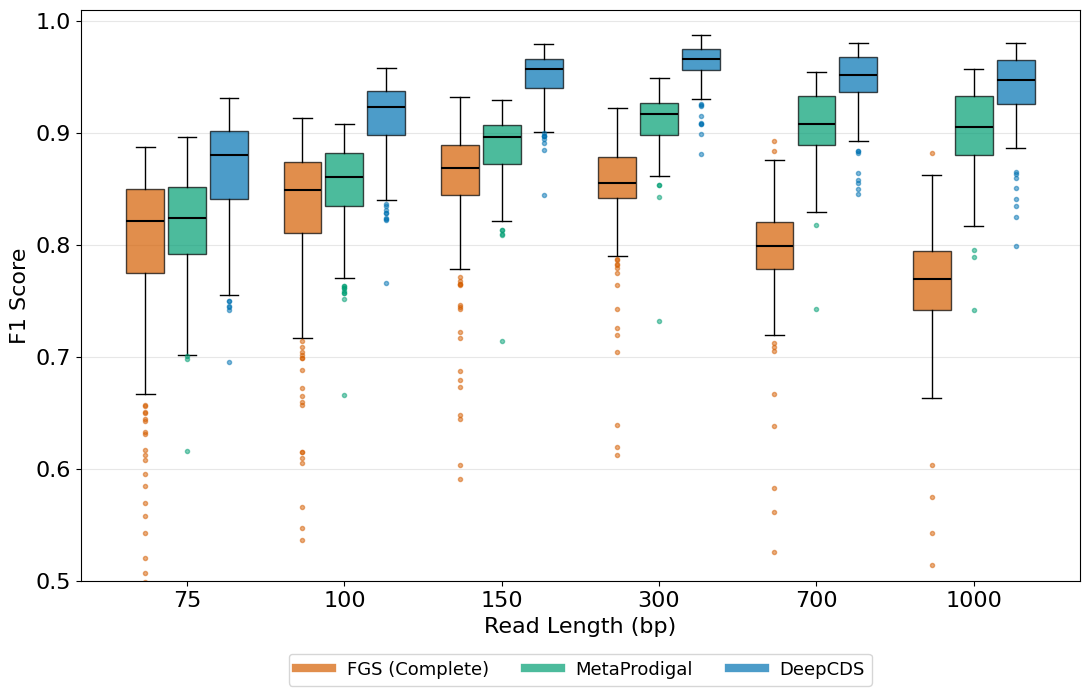

In [19]:
def plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, metric_name, ylabel):
    """Plot per-genome metric distributions as grouped boxplots across read lengths.

    All models are shown in a single figure. For each read length, one box per model
    is drawn side by side (mirroring the grouped bar chart layout). Models with no
    data at any read length are skipped.

    Args:
        per_genome_metrics_list: Dict of {length: {model: {metric_name: [values_per_genome]}}}.
        read_lengths: List of read lengths for the x-axis.
        metric_name: Key into metrics (e.g. 'f1_score', 'precision', 'recall').
        ylabel: Y-axis label and part of the plot title.
    """
    matplotlib.rcParams['text.usetex'] = False

    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[l][m][metric_name] for l in read_lengths)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    fig, ax = plt.subplots(figsize=(11, 7))

    x_positions = np.arange(len(read_lengths))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    for k, model in enumerate(active_models):
        color = model_colors[model]
        positions, data = [], []
        for i, length in enumerate(read_lengths):
            vals = per_genome_metrics_list[length][model][metric_name]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=model_display_names[model])

    ax.set_xlabel('Read Length (bp)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(l) for l in read_lengths])
    ax.set_ylim(0.5, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.20), loc='lower center', ncol=4)

    plt.tight_layout()
    # plt.savefig(f"cds_level_{metric_name}_by_read_length_boxplot.svg", dpi=500)
    plt.show()

plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'f1_score', 'F1 Score')

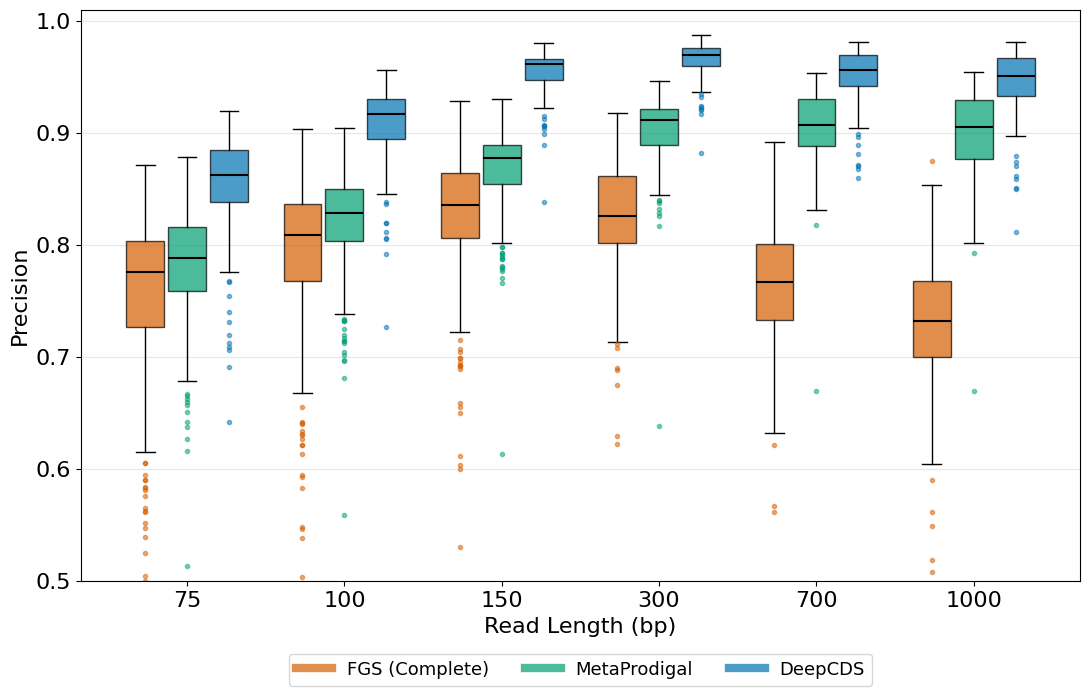

In [20]:
plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'precision', 'Precision')

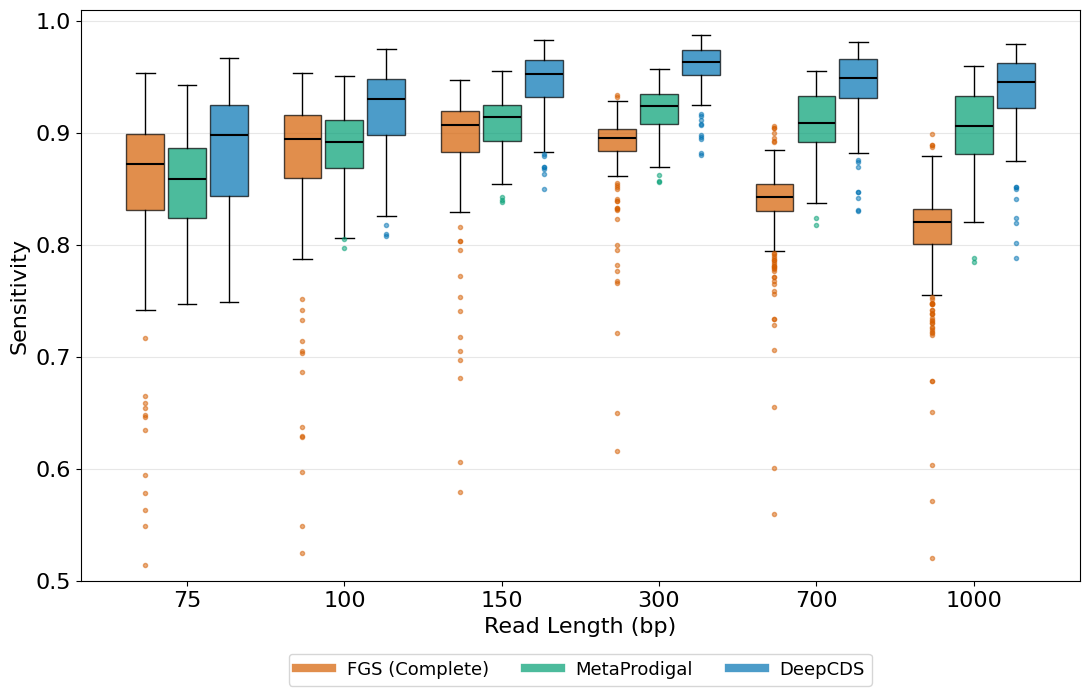

In [21]:
plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'recall', 'Sensitivity')

In [16]:
# Generate LaTeX table with 3 metric sections (F1, Sensitivity, Precision)
# Rows: model names grouped by metric; Columns: read lengths
# Best score per read length is bolded

metrics_order = [
    ('f1_score', 'F1 Score'),
    ('recall', 'Sensitivity'),
    ('precision', 'Precision'),
]

col_fmt = 'l' + 'c' * len(read_lengths)
header_cols = ' & '.join([f'{l}bp' for l in read_lengths])

lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(rf'\begin{{tabular}}{{{col_fmt}}}')
lines.append(r'\toprule')
lines.append(f' & {header_cols} \\\\')

for sec_idx, (metric_key, metric_label) in enumerate(metrics_order):
    lines.append(r'\midrule')
    lines.append(rf'\multicolumn{{{1 + len(read_lengths)}}}{{l}}{{\textbf{{{metric_label}}}}} \\')
    lines.append(r'\midrule')
    
    # Find best value per read length for this metric
    best_per_length = []
    for i in range(len(read_lengths)):
        col_vals = [aggregated_metrics[model][metric_key][i] for model in model_names]
        valid = [v for v in col_vals if not np.isnan(v)]
        best_per_length.append(max(valid) if valid else None)
    
    for model in model_names:
        display = model_display_names[model]
        vals = []
        for i, length in enumerate(read_lengths):
            v = aggregated_metrics[model][metric_key][i]
            if np.isnan(v):
                vals.append('--')
            elif best_per_length[i] is not None and v == best_per_length[i]:
                vals.append(rf'\textbf{{{v:.3f}}}')
            else:
                vals.append(f'{v:.3f}')
        row = f'{display} & ' + ' & '.join(vals) + r' \\'
        lines.append(row)

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\caption{TODO: WRITE CAPTION.}')
lines.append(r'\label{tab:cds_read_length_no_errors}')
lines.append(r'\end{table}')

latex_table = '\n'.join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\begin{tabular}{lcccccc}
\toprule
 & 75bp & 100bp & 150bp & 300bp & 700bp & 1000bp \\
\midrule
\multicolumn{7}{l}{\textbf{F1 Score}} \\
\midrule
FGS (Complete) & 0.813 & 0.841 & 0.863 & 0.855 & 0.796 & 0.766 \\
MetaProdigal & 0.819 & 0.855 & 0.889 & 0.913 & 0.910 & 0.906 \\
DeepCDS & \textbf{0.876} & \textbf{0.919} & \textbf{0.953} & \textbf{0.965} & \textbf{0.952} & \textbf{0.946} \\
\midrule
\multicolumn{7}{l}{\textbf{Sensitivity}} \\
\midrule
FGS (Complete) & 0.866 & 0.887 & 0.900 & 0.889 & 0.835 & 0.807 \\
MetaProdigal & 0.861 & 0.891 & 0.911 & 0.922 & 0.913 & 0.907 \\
DeepCDS & \textbf{0.894} & \textbf{0.926} & \textbf{0.949} & \textbf{0.962} & \textbf{0.949} & \textbf{0.942} \\
\midrule
\multicolumn{7}{l}{\textbf{Precision}} \\
\midrule
FGS (Complete) & 0.766 & 0.800 & 0.829 & 0.822 & 0.761 & 0.728 \\
MetaProdigal & 0.782 & 0.821 & 0.869 & 0.903 & 0.908 & 0.904 \\
DeepCDS & \textbf{0.860} & \textbf{0.913} & \textbf{0.958} & \textbf{0.967} & \textbf{0.